# GraphCast demo: 6-day prediction

Run **GraphCast_small** (1° resolution, 13 pressure levels) to predict the next 6 days of weather (24 × 6 h steps).

- **Model weights and normalization stats** are downloaded from GCS bucket dm_graphcast when not already present.
- **Data:** By default streams ERA5 from WeatherBench2 (no local download). Set `USE_ERA_STREAM = False` to use pre-downloaded data. Uses last 26 time steps (2 input + 24 target) via open_graphcast_era5.

**Requirements:** graphcast, JAX, Haiku, xarray. Optional google-cloud-storage for download.

**GPU:** By default the notebook uses CPU (avoids `CUDA_ERROR_NO_DEVICE` when no GPU is visible). To use GPU: (1) run the notebook on a GPU node (e.g. `USE_GPU=1 srun --gres=gpu:1 --pty jupyter notebook`), and (2) set env `USE_GPU=1` before starting the kernel. Run the GPU-check cell after the imports to confirm.

### GPU node allocation (e.g. on Della)

To run this notebook on a **GPU** from a cluster login node:

1. **Check available GPU nodes:** e.g. `sinfo -o "%P %G %f"`
2. **Allocate a GPU node:** e.g. `salloc --nodes=1 --ntasks=1 --mem=32G --time=02:00:00 --gres=gpu:a100:1`
- then use: `hostname` # check the compute node name (e.g. della-l03g3)
3. **On the compute node:** activate the env and start Jupyter:
   ```bash
   cd /scratch/gpfs/DABANIN/iv9432/Weather_global # change to your project root
   source scripts/graphcast_env.sh
   jupyter notebook --no-browser --port=8888 --ip=0.0.0.0
   ```
   Copy the URL it prints (you need the token). For example:
   http://della-l03g3:8888/tree?token=a6055fb5c1131fa84ae2fff3d89efc92b1f5e4fbffad892f
4. **From your local machine (not on the cluster):** SSH port forward so you can open the notebook in a browser. The compute hostname is only reachable from the cluster, so on your laptop run:
   ```bash
   ssh -L 8889:<COMPUTE_NODE>:8888 <USER>@della.princeton.edu
   ```
   Use the hostname from step 2 in place of `<COMPUTE_NODE>`. Then open `http://localhost:8889` in your browser and paste the token from step 3.

5. **In the notebook:** select the kernel: existing Jupyter kernel -> paste the URL from step 3 -> select the kernel "Python (graphcast311)"

In [3]:
import socket
import subprocess

# 1. Where is this kernel running?
print("Hostname (kernel runs on):", socket.gethostname())

# 2. Does this machine see a GPU? (optional; needs nvidia-smi)
try:
    out = subprocess.run(["nvidia-smi", "-L"], capture_output=True, text=True, timeout=5)
    print("GPUs visible to this node:", out.stdout.strip() or out.stderr.strip() or "none")
except Exception as e:
    print("nvidia-smi check:", e)

# 3. Does JAX see the GPU?
import jax
print("JAX backend:", jax.default_backend())
print("JAX devices:", jax.devices())

Hostname (kernel runs on): della-l04g13
GPUs visible to this node: GPU 0: NVIDIA A100 80GB PCIe (UUID: GPU-b4364426-ee8a-9173-d536-d2ec5c788c9f)
JAX backend: gpu
JAX devices: [CudaDevice(id=0)]


In [2]:
# import os; os.environ["USE_GPU"] = "1"
# os.environ["JAX_PLATFORMS"] = "GPU"

In [4]:
import os
import dataclasses
import functools
import sys
from pathlib import Path

import numpy as np
import xarray

from graphcast import autoregressive
from graphcast import casting
from graphcast import checkpoint
from graphcast import data_utils
from graphcast import graphcast
from graphcast import normalization
from graphcast import rollout
import haiku as hk
import jax

try:
    from google.cloud import storage
except ImportError:
    storage = None  # pip install google-cloud-storage for download

# Project root (notebook may run from scripts/ or project root)
ROOT = Path.cwd()
if ROOT.name == "scripts":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# Regridding helper mirroring scripts/regrid_resolution.py
REGRID_METHOD = "linear"  # change to "nearest" to match alternate preprocessing

def _target_axis(values, resolution, *, is_lon):
    arr = np.asarray(values.values, dtype=float)
    vmin = float(np.nanmin(arr))
    vmax = float(np.nanmax(arr))

    if is_lon and vmin >= 0.0 and vmax > 180.0:
        target = np.arange(0.0, 360.0, resolution, dtype=float)
    else:
        start = np.ceil(vmin / resolution) * resolution
        stop = np.floor(vmax / resolution) * resolution
        target = np.arange(start, stop + 0.5 * resolution, resolution, dtype=float)

    if target.size == 0:
        raise ValueError("Could not build target grid. Check input coordinates and resolution.")
    return np.round(target, 6)


def regrid_dataset_resolution(ds, resolution, method=None, lat_name="lat", lon_name="lon"):
    method = method or REGRID_METHOD
    if lat_name not in ds.coords or lon_name not in ds.coords:
        raise KeyError(f"Missing required coords: {lat_name!r}, {lon_name!r}")

    lat_desc = bool(ds[lat_name].values[0] > ds[lat_name].values[-1])
    ds_sorted = ds.sortby(lat_name).sortby(lon_name)

    target_lat = _target_axis(ds_sorted[lat_name], float(resolution), is_lon=False)
    target_lon = _target_axis(ds_sorted[lon_name], float(resolution), is_lon=True)

    out = ds_sorted.interp({lat_name: target_lat, lon_name: target_lon}, method=method)
    if lat_desc:
        out = out.sortby(lat_name, ascending=False)
    return out


In [5]:
# Allow running this cell even if setup/import cell was skipped.
if "ROOT" not in globals():
    ROOT = Path.cwd()
    if ROOT.name == "scripts":
        ROOT = ROOT.parent

DATA_DIR = ROOT / "data/graphcast/graphcast"
PARAMS_DIR = DATA_DIR / "params"
STATS_DIR = DATA_DIR / "stats"
DIR_PREFIX = "graphcast/"

# Stream ERA5 from WeatherBench2 (no local download). Set to False to use pre-downloaded data.
USE_ERA_STREAM = True
ERA_STREAM_URI = "gs://weatherbench2/datasets/era5/1959-2023_01_10-wb13-6h-1440x721_with_derived_variables.zarr"

if USE_ERA_STREAM:
    dataset_dir = ERA_STREAM_URI
else:
    # Pre-downloaded options (one of):
    # dataset_dir = DATA_DIR / "dataset/source-era5_wb13_latest-1y_res-1.0_levels-13_steps-all.zarr"
    dataset_dir = DATA_DIR / "dataset/source-era5_cds_rolling-last30d_res-1.0_levels-13_steps-04.nc"

# GraphCast_small params filename (set to None to auto-detect from GCS list)
PARAMS_FILENAME = None

if PARAMS_FILENAME is not None:
    params_path = PARAMS_DIR / PARAMS_FILENAME
else:
    params_path = None

print("ROOT:", ROOT)
print("DATA_DIR:", DATA_DIR)
if USE_ERA_STREAM:
    print("Data: streamed ERA5 from", ERA_STREAM_URI)
else:
    print("dataset_dir exists:", dataset_dir.exists())

ROOT: /scratch/gpfs/DABANIN/iv9432/Weather_global
DATA_DIR: /scratch/gpfs/DABANIN/iv9432/Weather_global/data/graphcast/graphcast
Data: streamed ERA5 from gs://weatherbench2/datasets/era5/1959-2023_01_10-wb13-6h-1440x721_with_derived_variables.zarr


In [6]:
DATA_DIR = ROOT / "data/graphcast/graphcast"
PARAMS_DIR = DATA_DIR / "params"
STATS_DIR = DATA_DIR / "stats"
# dataset_dir = DATA_DIR / "dataset/source-era5_wb13_latest-1y_res-1.0_levels-13_steps-all.zarr"
dataset_dir = DATA_DIR / "dataset/source-era5_cds_rolling-last30d_res-1.0_levels-13_steps-04.nc"
DIR_PREFIX = "graphcast/"

# GraphCast_small params filename (set to None to auto-detect from GCS list)
PARAMS_FILENAME = None

if PARAMS_FILENAME is not None:
    params_path = PARAMS_DIR / PARAMS_FILENAME
else:
    params_path = None

print("ROOT:", ROOT)
print("DATA_DIR:", DATA_DIR)
print("dataset_dir exists:", dataset_dir.exists())

ROOT: /scratch/gpfs/DABANIN/iv9432/Weather_global
DATA_DIR: /scratch/gpfs/DABANIN/iv9432/Weather_global/data/graphcast/graphcast
dataset_dir exists: True


In [7]:
PARAMS_DIR.mkdir(parents=True, exist_ok=True)
STATS_DIR.mkdir(parents=True, exist_ok=True)

STATS_FILES = ["diffs_stddev_by_level.nc", "mean_by_level.nc", "stddev_by_level.nc"]
stats_complete = all((STATS_DIR / f).exists() for f in STATS_FILES)

# If params_path not set, discover existing params file in PARAMS_DIR (e.g. manually downloaded)
if params_path is None:
    existing = list(PARAMS_DIR.glob("*small*.npz")) or list(PARAMS_DIR.glob("*.npz"))
    if existing:
        params_path = existing[0]

need_download = (params_path is None or not params_path.exists()) or not stats_complete

def _download_url(url, path, desc="file"):
    import urllib.request
    try:
        req = urllib.request.Request(url, headers={"User-Agent": "GraphCast-demo"})
        with urllib.request.urlopen(req, timeout=60) as resp:
            path.write_bytes(resp.read())
        print(f"Downloaded {desc}: {path.name}")
        return True
    except Exception as e:
        print(f"Could not download {url}: {e}")
        return False

GCS_BASE = "https://storage.googleapis.com/dm_graphcast/graphcast"
# Known GraphCast_small params filenames to try (bucket listing may use different naming)
PARAMS_CANDIDATES = [
    "params_GraphCast_small-ERA5_1979-2015-resolution_1.0-pressure_levels_13-mesh_size_2.npz",
    "GraphCast_small - ERA5 1979-2015 - resolution 1.0 - pressure levels 13 - mesh 2to5.npz",
]

if need_download and storage is not None:
    gcs_client = storage.Client.create_anonymous_client()
    gcs_bucket = gcs_client.get_bucket("dm_graphcast")

    blob_names = [
        b.name.removeprefix(DIR_PREFIX + "params/")
        for b in gcs_bucket.list_blobs(prefix=DIR_PREFIX + "params/")
        if b.name.removeprefix(DIR_PREFIX + "params/")
    ]
    small_options = [n for n in blob_names if "small" in n.lower()]
    best = [n for n in small_options if "1.0" in n and "13" in n]
    chosen = (best or small_options)[0] if (best or small_options) else None
    if chosen is None:
        raise FileNotFoundError(
            "No GraphCast_small params found in dm_graphcast. Available (first 5): "
            + str(blob_names[:5])
        )
    params_path = PARAMS_DIR / chosen

    if not params_path.exists():
        print("Downloading params:", chosen)
        blob = gcs_bucket.blob(DIR_PREFIX + "params/" + chosen)
        blob.download_to_filename(str(params_path))

    for fname in STATS_FILES:
        local = STATS_DIR / fname
        if not local.exists():
            print("Downloading stats:", fname)
            gcs_bucket.blob(DIR_PREFIX + "stats/" + fname).download_to_filename(str(local))
    print("Params path:", params_path)
elif need_download and storage is None:
    # No google-cloud-storage (e.g. no pip network): try public HTTPS with urllib
    import urllib.parse
    downloaded_params = False
    if params_path is None or not params_path.exists():
        for candidate in PARAMS_CANDIDATES:
            url = f"{GCS_BASE}/params/{urllib.parse.quote(candidate)}"
            path = PARAMS_DIR / candidate
            if _download_url(url, path, "params"):
                params_path = path
                downloaded_params = True
                break
        if not downloaded_params and (params_path is None or not params_path.exists()):
            raise FileNotFoundError(
                "Could not download params (no network or wrong URL). Install google-cloud-storage "
                "where pip works, or download manually from "
                "https://console.cloud.google.com/storage/browser/dm_graphcast/graphcast/params "
                "and place the GraphCast_small .npz file in:\n  " + str(PARAMS_DIR)
            )
    for fname in STATS_FILES:
        local = STATS_DIR / fname
        if not local.exists():
            if not _download_url(f"{GCS_BASE}/stats/{fname}", local, fname):
                raise FileNotFoundError(
                    f"Could not download {fname}. Place it manually in:\n  " + str(STATS_DIR)
                )
    if params_path is not None:
        print("Params path:", params_path)
else:
    if params_path is None:
        existing = list(PARAMS_DIR.glob("*small*.npz")) or list(PARAMS_DIR.glob("*.npz"))
        if existing:
            params_path = existing[0]
        else:
            raise FileNotFoundError("No params file found in " + str(PARAMS_DIR))
    print("Using existing params:", params_path)

Using existing params: /scratch/gpfs/DABANIN/iv9432/Weather_global/data/graphcast/graphcast/params/GraphCast_small - ERA5 1979-2015 - resolution 1.0 - pressure levels 13 - mesh 2to5 - precipitation input and output.npz


In [8]:
with open(params_path, "rb") as f:
    ckpt = checkpoint.load(f, graphcast.CheckPoint)
params = ckpt.params
state = {}
model_config = ckpt.model_config
task_config = ckpt.task_config
print("Model:", ckpt.description)
print("model_config.resolution:", model_config.resolution)
print("Pressure levels:", len(task_config.pressure_levels))

Model: 
Low resolution version of the GraphCast model (1deg, smaller mesh), with 37
pressure levels. This model is trained on ERA5 data from 1979 to 2015, and can
be causally evaluated on 2016 and later years. This model takes as inputs
`total_precipitation_6hr`. This model has much lower memory requirements.

model_config.resolution: 1.0
Pressure levels: 13


In [9]:
diffs_stddev_by_level = xarray.open_dataset(STATS_DIR / "diffs_stddev_by_level.nc").compute()
mean_by_level = xarray.open_dataset(STATS_DIR / "mean_by_level.nc").compute()
stddev_by_level = xarray.open_dataset(STATS_DIR / "stddev_by_level.nc").compute()
print("Normalization stats loaded.")

Normalization stats loaded.


In [10]:
from src.data.graphcast_dataset import open_graphcast_era5

n_steps_forecast = 24
n_steps_input = 2
n_steps_total = n_steps_forecast + n_steps_input
# Last n_steps_total steps: 2 for input (t-6h, t0), n_steps_forecast for 6-day targets (6h, 12h, ..., 144h)
ds = open_graphcast_era5(dataset_dir, time_slice=slice(-n_steps_total, None))
ds = ds.compute()

# Regrid to 1° for GraphCast_small-compatible evaluation (matches regrid_resolution.py logic)
ds = regrid_dataset_resolution(ds, 1.0, method=REGRID_METHOD)

# GraphCast data_utils expects time + datetime coords; convert hours since epoch to datetime64
import pandas as pd
if np.issubdtype(ds["time"].dtype, np.integer) or ds["time"].dtype.kind in "iu":
    times = pd.to_datetime(ds["time"].values, unit="h", origin="1959-01-01")
    ds = ds.assign_coords(time=("time", times))
# add_derived_vars requires "datetime" with same dims as data (batch, time) for progress features
if "batch" in ds.dims:
    dt = xarray.DataArray(ds["time"].values, dims=["time"]).expand_dims(batch=ds.sizes["batch"])
    ds = ds.assign_coords(datetime=dt)
else:
    ds = ds.assign_coords(datetime=("time", ds["time"].values))

print("Dataset time steps:", ds.sizes["time"])
print("Time coord (first, last):", ds["time"].values[0], ds["time"].values[-1])

Dataset time steps: 26
Time coord (first, last): 2026-02-09T18:00:00.000000000 2026-02-16T00:00:00.000000000


In [11]:
h_predicted = n_steps_forecast * 6
inputs, targets, forcings = data_utils.extract_inputs_targets_forcings(
    ds,
    target_lead_times=slice("6h", f"{h_predicted}h"),  # 24 steps = 6 days at 6h
    **dataclasses.asdict(task_config),
)

# GraphCast expects static inputs (e.g. geopotential_at_surface, land_sea_mask)
# to have no time dimension. Our dataset may give them (batch, time, lat, lon);
# collapse to (batch, lat, lon) by taking the first timestep.
from graphcast import graphcast as graphcast_module
for name in getattr(graphcast_module, "STATIC_VARS", ("geopotential_at_surface", "land_sea_mask")):
    if name in inputs and "time" in inputs[name].dims:
        inputs = inputs.assign({name: inputs[name].isel(time=0, drop=True)})

print("Inputs:", inputs.sizes)
print("Targets:", targets.sizes)
print("Forcings:", forcings.sizes)

Inputs: Frozen({'batch': 1, 'time': 2, 'lat': 181, 'lon': 360, 'level': 13})
Targets: Frozen({'batch': 1, 'time': 24, 'lat': 181, 'lon': 360, 'level': 13})
Forcings: Frozen({'batch': 1, 'time': 24, 'lat': 181, 'lon': 360})


In [12]:
def construct_wrapped_graphcast(model_config, task_config):
    predictor = graphcast.GraphCast(model_config, task_config)
    predictor = casting.Bfloat16Cast(predictor)
    predictor = normalization.InputsAndResiduals(
        predictor,
        diffs_stddev_by_level=diffs_stddev_by_level,
        mean_by_level=mean_by_level,
        stddev_by_level=stddev_by_level,
    )
    predictor = autoregressive.Predictor(predictor, gradient_checkpointing=False)
    return predictor


@hk.transform_with_state
def run_forward(model_config, task_config, inputs, targets_template, forcings):
    predictor = construct_wrapped_graphcast(model_config, task_config)
    return predictor(inputs, targets_template=targets_template, forcings=forcings)


def with_configs(fn):
    return functools.partial(fn, model_config=model_config, task_config=task_config)


def with_params(fn):
    return functools.partial(fn, params=params, state=state)


def drop_state(fn):
    return lambda **kw: fn(**kw)[0]


run_forward_jitted = drop_state(with_params(jax.jit(with_configs(run_forward.apply))))
print("Jitted predictor ready.")

Jitted predictor ready.


In [13]:
# Ensure static inputs have no time dim (required by GraphCast; safe if already fixed in data cell).
for name in getattr(graphcast, "STATIC_VARS", ("geopotential_at_surface", "land_sea_mask")):
    if name in inputs and "time" in inputs[name].dims:
        inputs = inputs.assign({name: inputs[name].isel(time=0, drop=True)})

assert model_config.resolution in (0, 360.0 / inputs.sizes["lon"]), (
    "Model resolution doesn't match data resolution."
)

predictions = rollout.chunked_prediction(
    run_forward_jitted,
    rng=jax.random.PRNGKey(0),
    inputs=inputs,
    targets_template=targets * np.nan,
    forcings=forcings,
)
print("Predictions:", predictions.sizes)
predictions

Predictions: Frozen({'time': 24, 'batch': 1, 'lat': 181, 'lon': 360, 'level': 13})


<xarray.Dataset> Size: 519MB
Dimensions:                  (time: 24, batch: 1, lat: 181, lon: 360, level: 13)
Coordinates:
  * time                     (time) timedelta64[ns] 192B 0 days 06:00:00 ... ...
  * batch                    (batch) int64 8B 0
  * lat                      (lat) float64 1kB 90.0 89.0 88.0 ... -89.0 -90.0
  * lon                      (lon) float64 3kB 0.0 1.0 2.0 ... 357.0 358.0 359.0
  * level                    (level) int32 52B 50 100 150 200 ... 850 925 1000
Data variables:
    10m_u_component_of_wind  (time, batch, lat, lon) float32 6MB 0.7788 ... 0...
    10m_v_component_of_wind  (time, batch, lat, lon) float32 6MB 1.225 ... -0...
    2m_temperature           (time, batch, lat, lon) float32 6MB 245.8 ... 236.2
    geopotential             (time, batch, level, lat, lon) float32 81MB 1.95...
    mean_sea_level_pressure  (time, batch, lat, lon) float32 6MB 1.038e+05 .....
    specific_humidity        (time, batch, level, lat, lon) float32 81MB 3.06...
    temperature              (time, batch, level, lat, lon) float32 81MB 208....
    total_precipitation_6hr  (time, batch, lat, lon) float32 6MB -2.305e-05 ....
    u_component_of_wind      (time, batch, level, lat, lon) float32 81MB -17....
    v_component_of_wind      (time, batch, level, lat, lon) float32 81MB -10....
    vertical_velocity        (time, batch, level, lat, lon) float32 81MB -0.0...

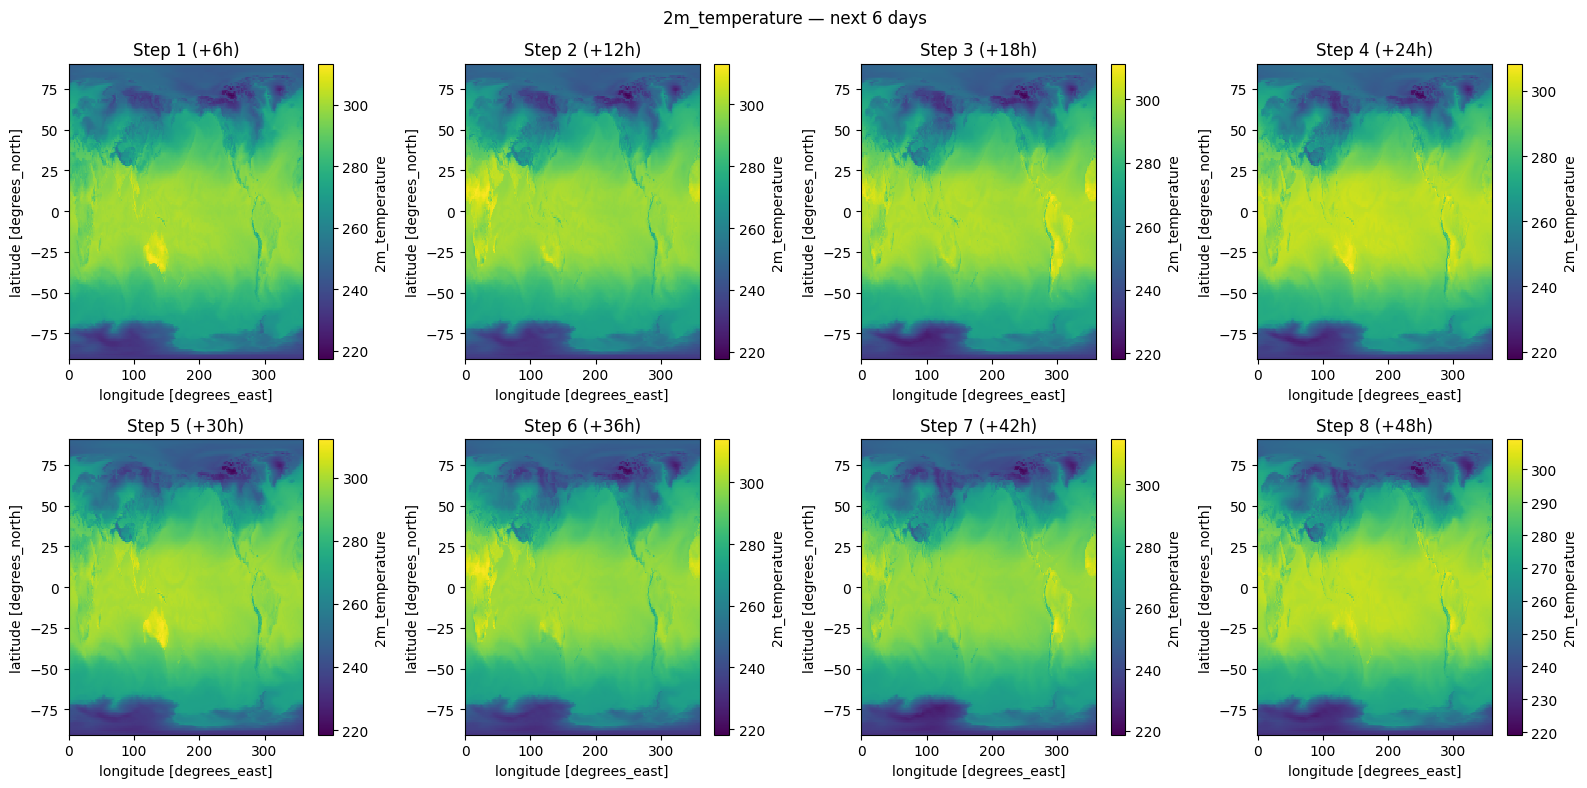

In [14]:
import matplotlib.pyplot as plt

variable = "2m_temperature"
n_steps = predictions.sizes.get("time", 1)
n_show = min(8, n_steps)  # show first 8 steps (2 days) of 6-day forecast
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for i in range(n_show):
    ax = axes[i]
    pred = predictions[variable].isel(batch=0, time=i)
    if "level" in pred.dims:
        pred = pred.isel(level=0)
    pred.plot(ax=ax, cmap="viridis")
    ax.set_title(f"Step {i + 1} (+{(i + 1) * 6}h)")
for j in range(n_show, len(axes)):
    axes[j].set_visible(False)
plt.suptitle(f"{variable} — next 6 days")
plt.tight_layout()
plt.show()

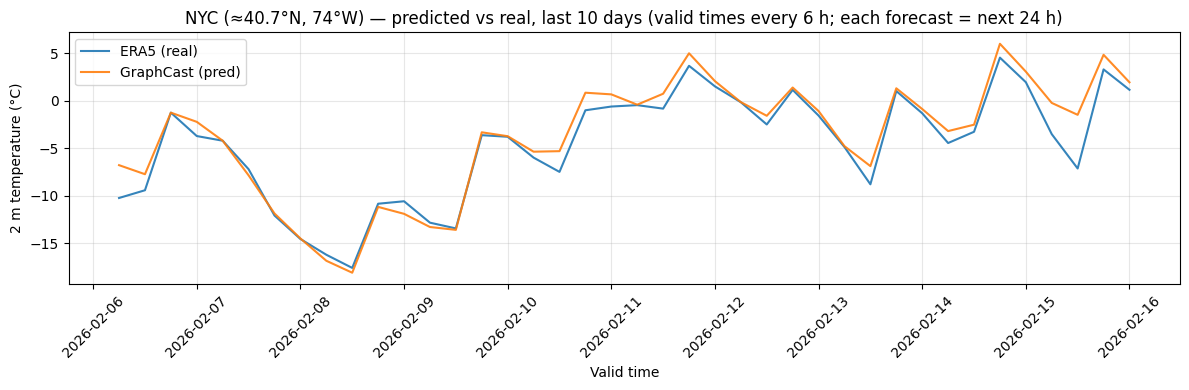

In [15]:
# NYC (approx): 40.7°N, 74°W → lon 286°E in 0–360
LAT_NYC, LON_NYC = 40.7, 360 - 74  # 286
n_days = 10
n_steps_per_day = 4
n_input_steps = 2
n_total_steps = n_input_steps + n_days * n_steps_per_day  # 42 for 10 days
from src.data.graphcast_dataset import open_graphcast_era5
ds_10d = open_graphcast_era5(dataset_dir, time_slice=slice(-n_total_steps, None))
ds_10d = ds_10d.compute()
# Regrid to 1° for GraphCast_small-compatible evaluation
ds_10d = regrid_dataset_resolution(ds_10d, 1.0, method=REGRID_METHOD)
n_available = ds_10d.sizes["time"]
n_days = min(n_days, (n_available - n_input_steps) // n_steps_per_day)
if n_days == 0:
    raise ValueError(f"Dataset has only {n_available} steps; need at least {n_input_steps + n_steps_per_day} for one day.")
ds_10d = ds_10d.isel(time=slice(-(n_input_steps + n_days * n_steps_per_day), None))
if np.issubdtype(ds_10d["time"].dtype, np.integer) or ds_10d["time"].dtype.kind in "iu":
    times_10d = pd.to_datetime(ds_10d["time"].values, unit="h", origin="1959-01-01")
    ds_10d = ds_10d.assign_coords(time=("time", times_10d))
if "batch" in ds_10d.dims:
    dt = xarray.DataArray(ds_10d["time"].values, dims=["time"]).expand_dims(batch=ds_10d.sizes["batch"])
    ds_10d = ds_10d.assign_coords(datetime=dt)
else:
    ds_10d = ds_10d.assign_coords(datetime=("time", ds_10d["time"].values))

from graphcast import graphcast as graphcast_module
lat_idx = int(np.argmin(np.abs(ds_10d["lat"].values - LAT_NYC)))
lon_idx = int(np.argmin(np.abs(ds_10d["lon"].values - LON_NYC)))

all_times = []
pred_nyc = []
real_nyc = []
for i in range(n_days):
    start = n_steps_per_day * i
    end = start + n_input_steps + n_steps_per_day
    ds_i = ds_10d.isel(time=slice(start, end))
    in_i, tgt_i, forc_i = data_utils.extract_inputs_targets_forcings(
        ds_i, target_lead_times=slice("6h", "24h"), **dataclasses.asdict(task_config)
    )
    for name in getattr(graphcast_module, "STATIC_VARS", ("geopotential_at_surface", "land_sea_mask")):
        if name in in_i and "time" in in_i[name].dims:
            in_i = in_i.assign({name: in_i[name].isel(time=0, drop=True)})
    pred_i = rollout.chunked_prediction(
        run_forward_jitted, rng=jax.random.PRNGKey(i),
        inputs=in_i, targets_template=tgt_i * np.nan, forcings=forc_i,
    )
    t_times = ds_i["time"].values[n_input_steps:]
    all_times.extend(t_times)
    pred_nyc.extend(pred_i["2m_temperature"].isel(batch=0, lat=lat_idx, lon=lon_idx).values.ravel().tolist())
    real_nyc.extend(tgt_i["2m_temperature"].isel(batch=0, lat=lat_idx, lon=lon_idx).values.ravel().tolist())

# Kelvin → Celsius
pred_nyc = np.array(pred_nyc) - 273.15
real_nyc = np.array(real_nyc) - 273.15

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(all_times, real_nyc, label="ERA5 (real)", color="C0", alpha=0.9)
ax.plot(all_times, pred_nyc, label="GraphCast (pred)", color="C1", alpha=0.9)
ax.set_ylabel("2 m temperature (°C)")
ax.set_xlabel("Valid time")
ax.set_title(f"NYC (≈40.7°N, 74°W) — predicted vs real, last {n_days} days (valid times every 6 h; each forecast = next 24 h)")
ax.legend(loc="best")
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Fine-tuned model

Run the same prediction (single 24h rollout + NYC 10-day) using a fine-tuned checkpoint.

In [16]:
# Fine-tuned checkpoint (same CheckPoint format as pretrained)
FINETUNED_CKPT = ROOT / "artifacts/checkpoints/graphcast_finetune_1y/a100_eval4/ckpt_step200.npz"
if not FINETUNED_CKPT.exists():
    raise FileNotFoundError(f"Fine-tuned checkpoint not found: {FINETUNED_CKPT}")

with open(FINETUNED_CKPT, "rb") as f:
    ckpt_finetuned = checkpoint.load(f, graphcast.CheckPoint)
params_finetuned = ckpt_finetuned.params
state_finetuned = {}

def with_params_finetuned(fn):
    return functools.partial(fn, params=params_finetuned, state=state_finetuned)

run_forward_jitted_finetuned = drop_state(with_params_finetuned(jax.jit(with_configs(run_forward.apply))))
print("Fine-tuned predictor ready:", ckpt_finetuned.description[:60], "...")

Fine-tuned predictor ready: 
Low resolution version of the GraphCast model (1deg, smalle ...


In [15]:
# Same single 24h rollout as above, but with fine-tuned model
predictions_finetuned = rollout.chunked_prediction(
    run_forward_jitted_finetuned,
    rng=jax.random.PRNGKey(0),
    inputs=inputs,
    targets_template=targets * np.nan,
    forcings=forcings,
)
print("Predictions (fine-tuned):", predictions_finetuned.sizes)
predictions_finetuned

Predictions (fine-tuned): Frozen({'time': 24, 'batch': 1, 'lat': 181, 'lon': 360, 'level': 13})


<xarray.Dataset> Size: 519MB
Dimensions:                  (time: 24, batch: 1, lat: 181, lon: 360, level: 13)
Coordinates:
  * time                     (time) timedelta64[ns] 192B 0 days 06:00:00 ... ...
  * batch                    (batch) int64 8B 0
  * lat                      (lat) float64 1kB 90.0 89.0 88.0 ... -89.0 -90.0
  * lon                      (lon) float64 3kB 0.0 1.0 2.0 ... 357.0 358.0 359.0
  * level                    (level) int32 52B 50 100 150 200 ... 850 925 1000
Data variables:
    10m_u_component_of_wind  (time, batch, lat, lon) float32 6MB 0.3112 ... 1...
    10m_v_component_of_wind  (time, batch, lat, lon) float32 6MB 1.379 ... -0...
    2m_temperature           (time, batch, lat, lon) float32 6MB 246.2 ... 230.0
    geopotential             (time, batch, level, lat, lon) float32 81MB 1.95...
    mean_sea_level_pressure  (time, batch, lat, lon) float32 6MB 1.038e+05 .....
    specific_humidity        (time, batch, level, lat, lon) float32 81MB 3.07...
    temperature              (time, batch, level, lat, lon) float32 81MB 208....
    total_precipitation_6hr  (time, batch, lat, lon) float32 6MB -0.0003643 ....
    u_component_of_wind      (time, batch, level, lat, lon) float32 81MB -21....
    v_component_of_wind      (time, batch, level, lat, lon) float32 81MB -16....
    vertical_velocity        (time, batch, level, lat, lon) float32 81MB -0.0...

**How this plot is built:** For each of 40 valid times (10 days × 4 per day), we run one **24-step (6-day) forecast** from initial conditions 6 days before that valid time, then keep **only the last step** (step 24) as the prediction. So each point on the x-axis is a **valid time**; the y-axis is 2 m temperature (°C). We plot three series: ERA5 (real), baseline prediction, and fine-tuned prediction.

**Why early times could be less accurate:** The leftmost points use initial conditions from the start of the **evaluation window**. If that start coincided with the very beginning of the loaded data, boundary effects (or lack of warm-up data) could hurt accuracy. **To reduce this we load a longer segment (80 steps)** and still only evaluate the last 40 valid times, so the first IC used is 14 steps inside the segment rather than at the boundary.

In [36]:
# NYC: 6-day lead (last step only) — baseline vs fine-tuned vs ERA5
# For each valid time we run one 24-step (6-day) forecast from IC 6 days before; use only step 24.
LAT_NYC, LON_NYC = 40.7, 360 - 74

# Shared lead-time config used by NYC eval cells below.
HOURS_PER_STEP = 6
TARGET_LEAD_DAYS = 4
TARGET_LEAD_HOURS = TARGET_LEAD_DAYS * 24
# TARGET_LEAD_HOURS = 48
TARGET_LEAD_TIMES = slice(f"{HOURS_PER_STEP}h", f"{TARGET_LEAD_HOURS}h")  # 6h..144h

n_eval_days = 40
n_steps_per_day = 24 // HOURS_PER_STEP
n_input_steps = 2
n_forecast_steps = TARGET_LEAD_HOURS // HOURS_PER_STEP  # 24 steps for 6-day lead
n_context_steps = n_input_steps + n_forecast_steps  # 26
n_target_times = n_eval_days * n_steps_per_day  # 160 valid times (40 days x 4/day)
n_extra_steps = 14  # buffer so first IC is inside segment (reduces boundary effect on early times)
n_total_steps = n_context_steps + n_target_times + n_extra_steps

ds_nyc = open_graphcast_era5(dataset_dir, time_slice=slice(-n_total_steps, None))
ds_nyc = ds_nyc.compute()
# Regrid to 1° for GraphCast_small-compatible evaluation.
ds_nyc = regrid_dataset_resolution(ds_nyc, 1.0, method=REGRID_METHOD)

n_steps = ds_nyc.sizes["time"]
if n_steps < n_context_steps + n_target_times:
    n_target_times = n_steps - n_context_steps
    n_eval_days = n_target_times // n_steps_per_day
if n_target_times <= 0:
    raise ValueError(
        f"Dataset has only {n_steps} steps; need at least {n_context_steps + n_steps_per_day} steps for one day."
    )
if np.issubdtype(ds_nyc["time"].dtype, np.integer) or ds_nyc["time"].dtype.kind in "iu":
    times_nyc = pd.to_datetime(ds_nyc["time"].values, unit="h", origin="1959-01-01")
    ds_nyc = ds_nyc.assign_coords(time=("time", times_nyc))
if "batch" in ds_nyc.dims:
    dt_nyc = xarray.DataArray(ds_nyc["time"].values, dims=["time"]).expand_dims(batch=ds_nyc.sizes["batch"])
    ds_nyc = ds_nyc.assign_coords(datetime=dt_nyc)
else:
    ds_nyc = ds_nyc.assign_coords(datetime=("time", ds_nyc["time"].values))

lat_idx_nyc = int(np.argmin(np.abs(ds_nyc["lat"].values - LAT_NYC)))
lon_idx_nyc = int(np.argmin(np.abs(ds_nyc["lon"].values - LON_NYC))
)

all_times_nyc = []
pred_baseline_nyc = []
pred_finetuned_nyc = []
real_nyc = []
start_target_idx = n_steps - n_target_times

print(
    f"NYC eval configured for {TARGET_LEAD_DAYS}-day lead "
    f"({n_forecast_steps} autoregressive steps of {HOURS_PER_STEP}h)."
)

NYC eval configured for 4-day lead (16 autoregressive steps of 6h).


/home/iv9432/.conda/envs/graphcast311/lib/python3.11/site-packages/graphcast/rollout.py:295: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  num_target_steps = targets_template.dims["time"]
/home/iv9432/.conda/envs/graphcast311/lib/python3.11/site-packages/graphcast/rollout.py:400: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  num_inputs = prev_inputs.dims["time"]
/home/iv9432/.conda/envs/graphcast311/lib/python3.11/site-packages/graphcast/rollout.py:402: FutureWarning: In a future version of xarray the default value for compat will change from compat='equals' to compat='override'. This chan

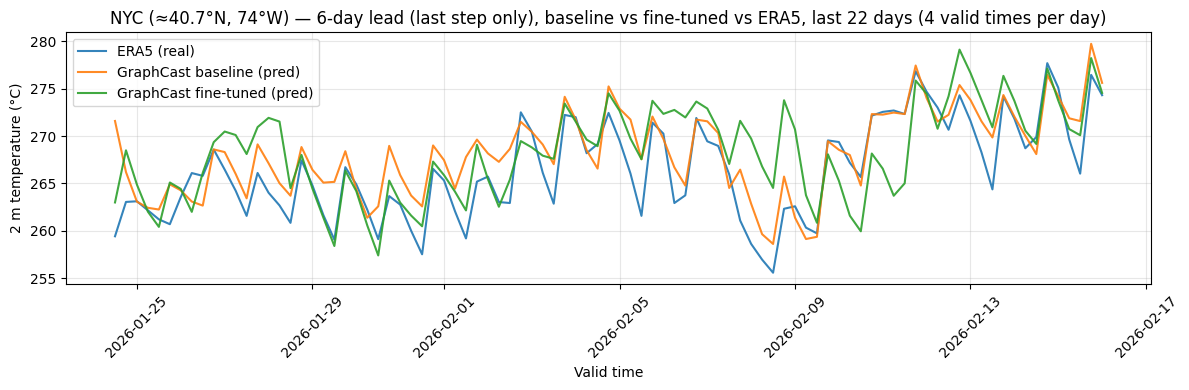

In [ ]:
# # FINE-TUNED MODEL

# for target_idx in range(start_target_idx, n_steps):
#     window = ds_nyc.isel(time=slice(target_idx - n_context_steps + 1, target_idx + 1))
#     in_i, tgt_i, forc_i = data_utils.extract_inputs_targets_forcings(
#         window, target_lead_times=TARGET_LEAD_TIMES, **dataclasses.asdict(task_config)
#     )
#     for name in getattr(graphcast_module, "STATIC_VARS", ("geopotential_at_surface", "land_sea_mask")):
#         if name in in_i and "time" in in_i[name].dims:
#             in_i = in_i.assign({name: in_i[name].isel(time=0, drop=True)})
#     pred_baseline_i = rollout.chunked_prediction(
#         run_forward_jitted, rng=jax.random.PRNGKey(target_idx),
#         inputs=in_i, targets_template=tgt_i * np.nan, forcings=forc_i,
#     )
#     pred_ft_i = rollout.chunked_prediction(
#         run_forward_jitted_finetuned, rng=jax.random.PRNGKey(target_idx + 1000),
#         inputs=in_i, targets_template=tgt_i * np.nan, forcings=forc_i,
#     )
#     all_times_nyc.append(ds_nyc["time"].values[target_idx])
#     pred_baseline_nyc.append(float(pred_baseline_i["2m_temperature"].isel(time=-1, batch=0, lat=lat_idx_nyc, lon=lon_idx_nyc).values))
#     pred_finetuned_nyc.append(float(pred_ft_i["2m_temperature"].isel(time=-1, batch=0, lat=lat_idx_nyc, lon=lon_idx_nyc).values))
#     real_nyc.append(float(ds_nyc["2m_temperature"].isel(time=target_idx, batch=0, lat=lat_idx_nyc, lon=lon_idx_nyc).values))

# fig, ax = plt.subplots(figsize=(12, 4))
# ax.plot(all_times_nyc, real_nyc, label="ERA5 (real)", color="C0", alpha=0.9)
# ax.plot(all_times_nyc, pred_baseline_nyc, label="GraphCast baseline (pred)", color="C1", alpha=0.9)
# ax.plot(all_times_nyc, pred_finetuned_nyc, label="GraphCast fine-tuned (pred)", color="C2", alpha=0.9)
# ax.set_ylabel("2 m temperature (°C)")
# ax.set_xlabel("Valid time")
# ax.set_title(
#     f"NYC (≈40.7°N, 74°W) — {TARGET_LEAD_DAYS}-day lead (last step only), "
#     f"baseline vs fine-tuned vs ERA5, last {n_eval_days} days (4 valid times per day)"
# )
# ax.legend(loc="best")
# ax.grid(True, alpha=0.3)
# plt.xticks(rotation=45)
# plt.tight_layout()
# plt.show()

### smal models, res = 2


In [23]:
# Regrid NYC evaluation dataset for res=2 and res=4 models using regrid_resolution.py logic
if "ds_nyc" not in globals():
    raise NameError("ds_nyc is not defined. Run the NYC ERA5 loading cell first.")
if "TARGET_LEAD_DAYS" not in globals():
    raise NameError("TARGET_LEAD_DAYS is not defined. Run the NYC lead-time config cell first.")

ds_nyc_res2 = regrid_dataset_resolution(ds_nyc, 2.0, method=REGRID_METHOD)
ds_nyc_res4 = regrid_dataset_resolution(ds_nyc, 4.0, method=REGRID_METHOD)
print("ds_nyc grid:", ds_nyc.sizes.get("lat"), "x", ds_nyc.sizes.get("lon"))
print("ds_nyc_res2 grid:", ds_nyc_res2.sizes.get("lat"), "x", ds_nyc_res2.sizes.get("lon"))
print("ds_nyc_res4 grid:", ds_nyc_res4.sizes.get("lat"), "x", ds_nyc_res4.sizes.get("lon"))
print(f"Regrid method: {REGRID_METHOD}")
print(f"Evaluation target lead: {TARGET_LEAD_DAYS} days ({TARGET_LEAD_HOURS}h)")


ds_nyc grid: 181 x 360
ds_nyc_res2 grid: 91 x 180
Evaluation target lead: 2 days (48h)


In [37]:
# NYC: 6-day lead — res2_stream checkpoints vs ERA5 (baseline GraphCast commented out)
# Uses checkpoints from artifacts/checkpoints/graphcast_res2_stream (res2 models may be 2°; data is downsampled when needed).
import matplotlib.pyplot as plt
import re
from graphcast import graphcast as graphcast_module


if "TARGET_LEAD_TIMES" not in globals():
    raise NameError("TARGET_LEAD_TIMES is not defined. Run the NYC lead-time config cell first.")

RES2_CKPT_DIR = ROOT / "artifacts/checkpoints/graphcast_res2_stream"
ckpt_paths = []
for run_dir in sorted(RES2_CKPT_DIR.glob("res2_*")):
    if not run_dir.is_dir():
        continue
    candidates = []
    for p in run_dir.glob("ckpt_step*.npz"):
        m = re.search(r"ckpt_step(\d+)$", p.stem)
        if m:
            candidates.append((int(m.group(1)), p))
    if candidates:
        ckpt_paths.append(max(candidates, key=lambda x: x[0])[1])

def _with_configs_ckpt(fn, model_config, task_config):
    return functools.partial(fn, model_config=model_config, task_config=task_config)

def _with_params_ckpt(fn, params, state):
    return functools.partial(fn, params=params, state=state)

# Each item stores prediction and ERA5 extracted on the SAME grid/point.
# dict keys: label, pred_nyc, real_nyc_res
res2_results = []
regrid_cache = {1: ds_nyc, 2: globals().get("ds_nyc_res2", regrid_dataset_resolution(ds_nyc, 2.0, method=REGRID_METHOD)), 4: globals().get("ds_nyc_res4", regrid_dataset_resolution(ds_nyc, 4.0, method=REGRID_METHOD))}

# Time axis shared across checkpoints (time length is unchanged by lat/lon downsampling)
all_times_nyc = ds_nyc["time"].values[start_target_idx:n_steps]
print(f"Evaluating checkpoints at target lead {TARGET_LEAD_DAYS} days ({TARGET_LEAD_HOURS}h, {n_forecast_steps} steps).")

for ckpt_path in ckpt_paths:
    with ckpt_path.open("rb") as f:
        ckpt = checkpoint.load(f, graphcast.CheckPoint)
    model_cfg = ckpt.model_config
    task_cfg = ckpt.task_config
    res = getattr(model_cfg, "resolution", 1.0)
    stride = max(1, int(round(res)))  # 1° -> 1, 2° -> 2
    if stride not in regrid_cache:
        regrid_cache[stride] = regrid_dataset_resolution(ds_nyc, float(stride), method=REGRID_METHOD)
    ds_res = regrid_cache[stride]
    lat_idx = int(np.argmin(np.abs(ds_res["lat"].values - LAT_NYC)))
    lon_idx = int(np.argmin(np.abs(ds_res["lon"].values - LON_NYC)))

    run_name = ckpt_path.parent.name
    m_h = re.search(r"_h(\d+)_", run_name)
    if m_h and int(m_h.group(1)) == 6 and TARGET_LEAD_HOURS > 6:
        print(f"Warning: {run_name} appears trained for +6h objective, but evaluated at {TARGET_LEAD_HOURS}h lead.")

    run_jitted = drop_state(_with_params_ckpt(jax.jit(_with_configs_ckpt(run_forward.apply, model_cfg, task_cfg)), ckpt.params, {}))
    pred_nyc = []
    real_nyc_res = []
    for target_idx in range(start_target_idx, n_steps):
        window = ds_res.isel(time=slice(target_idx - n_context_steps + 1, target_idx + 1))
        in_i, tgt_i, forc_i = data_utils.extract_inputs_targets_forcings(
            window, target_lead_times=TARGET_LEAD_TIMES, **dataclasses.asdict(task_cfg)
        )
        for name in getattr(graphcast_module, "STATIC_VARS", ("geopotential_at_surface", "land_sea_mask")):
            if name in in_i and "time" in in_i[name].dims:
                in_i = in_i.assign({name: in_i[name].isel(time=0, drop=True)})
        pred_i = rollout.chunked_prediction(
            run_jitted, rng=jax.random.PRNGKey(target_idx + 2000 + len(res2_results)),
            inputs=in_i, targets_template=tgt_i * np.nan, forcings=forc_i,
        )
        pred_nyc.append(float(pred_i["2m_temperature"].isel(time=-1, batch=0, lat=lat_idx, lon=lon_idx).values))
        real_nyc_res.append(float(ds_res["2m_temperature"].isel(time=target_idx, batch=0, lat=lat_idx, lon=lon_idx).values))

    pred_arr = np.asarray(pred_nyc)
    real_arr = np.asarray(real_nyc_res)
    if pred_arr.size > 0 and np.median(pred_arr) > 200:
        pred_arr = pred_arr - 273.15
    if real_arr.size > 0 and np.median(real_arr) > 200:
        real_arr = real_arr - 273.15

    label = f"{run_name} (step {ckpt_path.stem.replace('ckpt_step', '')})"
    res2_results.append({"label": label, "pred_nyc": pred_arr, "real_nyc_res": real_arr})

Evaluating checkpoints at target lead 4 days (96h, 16 steps).


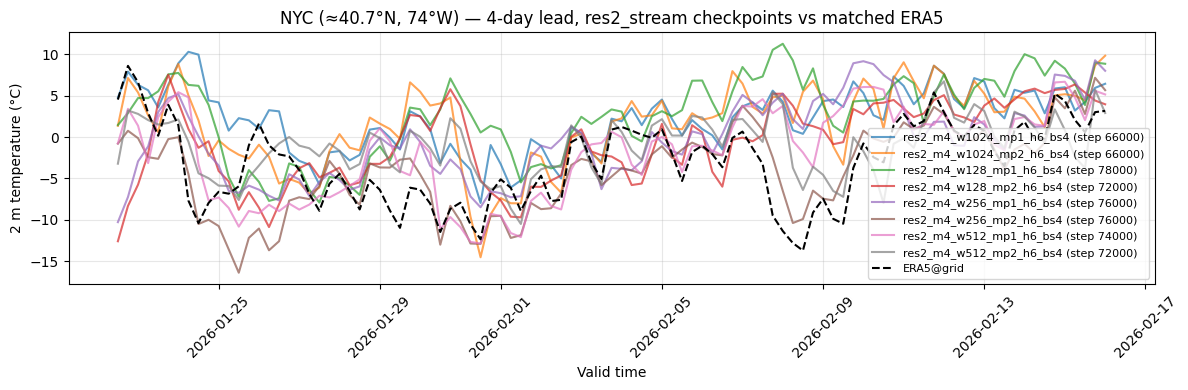

In [38]:
fig, ax = plt.subplots(figsize=(12, 4))
for item in res2_results:
    label = item["label"]
    pred_arr = np.asarray(item["pred_nyc"])
    real_arr = np.asarray(item["real_nyc_res"])
    n = min(len(all_times_nyc), len(pred_arr), len(real_arr))
    if n == 0:
        continue
    ax.plot(all_times_nyc[:n], pred_arr[:n], alpha=0.7, label=label)
ax.plot(all_times_nyc[:n], real_arr[:n], linestyle="--", alpha=1.0, label=f"ERA5@grid", color = "black")
ax.set_ylabel("2 m temperature (°C)")
ax.set_xlabel("Valid time")
ax.set_title(f"NYC (≈40.7°N, 74°W) — {TARGET_LEAD_DAYS}-day lead, res2_stream checkpoints vs matched ERA5")
ax.legend(loc="best", fontsize=8)
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
if not res2_results:
    print("No ckpt_*.npz found under", RES2_CKPT_DIR)

In [39]:
if "res2_results" not in globals() or len(res2_results) == 0:
    raise RuntimeError("res2_results is empty. Run the checkpoint evaluation cell first.")
if "all_times_nyc" not in globals():
    raise RuntimeError("all_times_nyc is missing. Run the checkpoint evaluation cell first.")

# Mean absolute error over valid times for each checkpoint/model.
metrics = []
for item in res2_results:
    if isinstance(item, dict):
        label = item.get("label", "checkpoint")
        pred_arr = np.asarray(item.get("pred_nyc", []))
        real_arr = np.asarray(item.get("real_nyc_res", []))
    else:
        # Legacy path: (label, pred_nyc). Rebuild ERA5 truth on explicit res=2 grid.
        if "ds_nyc_res2" not in globals():
            raise RuntimeError("Legacy res2_results detected and ds_nyc_res2 missing. Run the res=2 downsample cell first.")
        label, pred_old = item
        pred_arr = np.asarray(pred_old)
        lat_idx_res2 = int(np.argmin(np.abs(ds_nyc_res2["lat"].values - LAT_NYC)))
        lon_idx_res2 = int(np.argmin(np.abs(ds_nyc_res2["lon"].values - LON_NYC)))
        real_arr = np.array([
            float(ds_nyc_res2["2m_temperature"].isel(time=ti, batch=0, lat=lat_idx_res2, lon=lon_idx_res2).values)
            for ti in range(start_target_idx, n_steps)
        ])
        if real_arr.size > 0 and np.median(real_arr) > 200:
            real_arr = real_arr - 273.15

    n = min(len(all_times_nyc), len(pred_arr), len(real_arr))
    if n == 0:
        print(f"Skipping {label}: empty series (pred={len(pred_arr)}, real={len(real_arr)}, time={len(all_times_nyc)})")
        continue

    err = np.abs(pred_arr[:n] - real_arr[:n])
    metrics.append((label, float(np.mean(err)), float(np.max(err)), int(n)))

if not metrics:
    print("No comparable prediction/ERA5 points to score. Re-run the checkpoint evaluation cell first.")
else:
    metrics.sort(key=lambda x: x[1])
    print(f"NYC {TARGET_LEAD_DAYS}-day lead — mean absolute error (°C), lower is better")
    for label, mae, maxe, n in metrics:
        print(f"{label:55s} MAE={mae:6.3f}  MAX={maxe:6.3f}  N={n}")

NYC 4-day lead — mean absolute error (°C), lower is better
res2_m4_w256_mp2_h6_bs4 (step 76000)                    MAE= 2.982  MAX=12.700  N=99
res2_m4_w512_mp2_h6_bs4 (step 72000)                    MAE= 3.534  MAX=15.337  N=99
res2_m4_w512_mp1_h6_bs4 (step 74000)                    MAE= 3.828  MAX=15.120  N=99
res2_m4_w256_mp1_h6_bs4 (step 76000)                    MAE= 4.877  MAX=16.594  N=99
res2_m4_w128_mp2_h6_bs4 (step 72000)                    MAE= 5.014  MAX=17.129  N=99
res2_m4_w1024_mp2_h6_bs4 (step 66000)                   MAE= 5.288  MAX=19.192  N=99
res2_m4_w1024_mp1_h6_bs4 (step 66000)                   MAE= 5.347  MAX=20.370  N=99
res2_m4_w128_mp1_h6_bs4 (step 78000)                    MAE= 6.513  MAX=22.639  N=99


In [ ]:
# NYC: 6-day lead — res4_stream checkpoints vs matched ERA5 + MAE summary
import re
from graphcast import graphcast as graphcast_module

if "TARGET_LEAD_TIMES" not in globals():
    raise NameError("TARGET_LEAD_TIMES is not defined. Run the NYC lead-time config cell first.")

RES4_CKPT_DIR = ROOT / "artifacts/checkpoints/graphcast_res4_stream"
ckpt_paths_res4 = []
for run_dir in sorted(RES4_CKPT_DIR.glob("res4_*")):
    if not run_dir.is_dir():
        continue
    candidates = []
    for p in run_dir.glob("ckpt_step*.npz"):
        m = re.search(r"ckpt_step(\d+)$", p.stem)
        if m:
            candidates.append((int(m.group(1)), p))
    if candidates:
        ckpt_paths_res4.append(max(candidates, key=lambda x: x[0])[1])

if not ckpt_paths_res4:
    raise RuntimeError(f"No ckpt_*.npz found under {RES4_CKPT_DIR}")

def _with_configs_ckpt_res4(fn, model_config, task_config):
    return functools.partial(fn, model_config=model_config, task_config=task_config)

def _with_params_ckpt_res4(fn, params, state):
    return functools.partial(fn, params=params, state=state)

res4_results = []  # dicts: label, pred_nyc, real_nyc_res
regrid_cache_res4 = {1: ds_nyc, 2: globals().get("ds_nyc_res2", regrid_dataset_resolution(ds_nyc, 2.0, method=REGRID_METHOD)), 4: globals().get("ds_nyc_res4", regrid_dataset_resolution(ds_nyc, 4.0, method=REGRID_METHOD))}
all_times_nyc_res4 = ds_nyc["time"].values[start_target_idx:n_steps]
print(f"Evaluating res4 checkpoints at target lead {TARGET_LEAD_DAYS} days ({TARGET_LEAD_HOURS}h, {n_forecast_steps} steps).")

for ckpt_path in ckpt_paths_res4:
    with ckpt_path.open("rb") as f:
        ckpt = checkpoint.load(f, graphcast.CheckPoint)
    model_cfg = ckpt.model_config
    task_cfg = ckpt.task_config

    res = float(getattr(model_cfg, "resolution", 1.0))
    stride = max(1, int(round(res)))
    if stride != 4:
        print(f"Warning: {ckpt_path.parent.name} has resolution={res}, expected ~4.0")

    if stride not in regrid_cache_res4:
        regrid_cache_res4[stride] = regrid_dataset_resolution(ds_nyc, float(stride), method=REGRID_METHOD)
    ds_res = regrid_cache_res4[stride]

    lat_idx = int(np.argmin(np.abs(ds_res["lat"].values - LAT_NYC)))
    lon_idx = int(np.argmin(np.abs(ds_res["lon"].values - LON_NYC)))

    run_jitted = drop_state(
        _with_params_ckpt_res4(
            jax.jit(_with_configs_ckpt_res4(run_forward.apply, model_cfg, task_cfg)),
            ckpt.params,
            {},
        )
    )

    pred_nyc = []
    real_nyc_res = []
    for target_idx in range(start_target_idx, n_steps):
        window = ds_res.isel(time=slice(target_idx - n_context_steps + 1, target_idx + 1))
        in_i, tgt_i, forc_i = data_utils.extract_inputs_targets_forcings(
            window, target_lead_times=TARGET_LEAD_TIMES, **dataclasses.asdict(task_cfg)
        )
        for name in getattr(graphcast_module, "STATIC_VARS", ("geopotential_at_surface", "land_sea_mask")):
            if name in in_i and "time" in in_i[name].dims:
                in_i = in_i.assign({name: in_i[name].isel(time=0, drop=True)})

        pred_i = rollout.chunked_prediction(
            run_jitted,
            rng=jax.random.PRNGKey(target_idx + 4000 + len(res4_results)),
            inputs=in_i,
            targets_template=tgt_i * np.nan,
            forcings=forc_i,
        )

        pred_nyc.append(float(pred_i["2m_temperature"].isel(time=-1, batch=0, lat=lat_idx, lon=lon_idx).values))
        real_nyc_res.append(float(ds_res["2m_temperature"].isel(time=target_idx, batch=0, lat=lat_idx, lon=lon_idx).values))

    pred_arr = np.asarray(pred_nyc)
    real_arr = np.asarray(real_nyc_res)
    if pred_arr.size > 0 and np.median(pred_arr) > 200:
        pred_arr = pred_arr - 273.15
    if real_arr.size > 0 and np.median(real_arr) > 200:
        real_arr = real_arr - 273.15

    label = f"{ckpt_path.parent.name} (step {ckpt_path.stem.replace('ckpt_step', '')})"
    res4_results.append({"label": label, "pred_nyc": pred_arr, "real_nyc_res": real_arr})


Evaluating res4 checkpoints at target lead 4 days (96h, 16 steps).


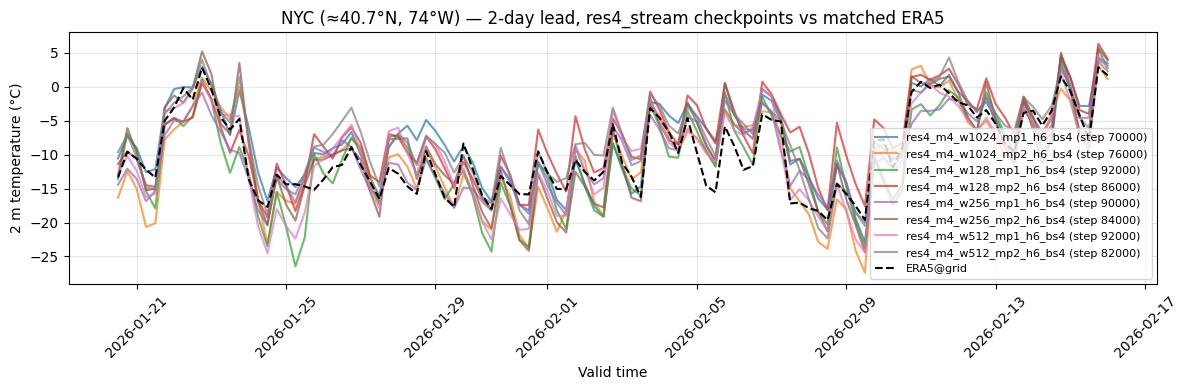

NYC 2-day lead (res4) — mean absolute error (°C), lower is better
res4_m4_w256_mp1_h6_bs4 (step 90000)                    MAE= 2.120  MAX= 6.749  N=107
res4_m4_w1024_mp2_h6_bs4 (step 76000)                   MAE= 2.519  MAX= 8.415  N=107
res4_m4_w1024_mp1_h6_bs4 (step 70000)                   MAE= 2.524  MAX= 8.951  N=107
res4_m4_w512_mp2_h6_bs4 (step 82000)                    MAE= 2.528  MAX= 8.594  N=107
res4_m4_w512_mp1_h6_bs4 (step 92000)                    MAE= 2.590  MAX= 8.013  N=107
res4_m4_w256_mp2_h6_bs4 (step 84000)                    MAE= 2.799  MAX= 8.296  N=107
res4_m4_w128_mp2_h6_bs4 (step 86000)                    MAE= 2.961  MAX=11.174  N=107
res4_m4_w128_mp1_h6_bs4 (step 92000)                    MAE= 2.991  MAX=12.116  N=107


In [ ]:

# Plot matched trajectories
fig, ax = plt.subplots(figsize=(12, 4))
for item in res4_results:
    label = item["label"]
    pred_arr = np.asarray(item["pred_nyc"])
    real_arr = np.asarray(item["real_nyc_res"])
    n = min(len(all_times_nyc_res4), len(pred_arr), len(real_arr))
    if n == 0:
        continue
    # ax.plot(all_times_nyc_res4[:n], real_arr[:n], linestyle="--", alpha=0.35, label=f"{label} ERA5@grid")
    ax.plot(all_times_nyc_res4[:n], pred_arr[:n], alpha=0.7, label=label)
ax.plot(all_times_nyc_res4[:n], real_arr[:n], linestyle="--", alpha=1., label="ERA5@grid", color="black")
ax.set_ylabel("2 m temperature (°C)")
ax.set_xlabel("Valid time")
ax.set_title(f"NYC (≈40.7°N, 74°W) — {TARGET_LEAD_DAYS}-day lead, res4_stream checkpoints vs matched ERA5")
ax.legend(loc="best", fontsize=8)
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# MAE summary
metrics_res4 = []
for item in res4_results:
    label = item["label"]
    pred_arr = np.asarray(item["pred_nyc"])
    real_arr = np.asarray(item["real_nyc_res"])
    n = min(len(all_times_nyc_res4), len(pred_arr), len(real_arr))
    if n == 0:
        print(f"Skipping {label}: empty series (pred={len(pred_arr)}, real={len(real_arr)}, time={len(all_times_nyc_res4)})")
        continue
    err = np.abs(pred_arr[:n] - real_arr[:n])
    metrics_res4.append((label, float(np.mean(err)), float(np.max(err)), int(n)))

if not metrics_res4:
    print("No comparable prediction/ERA5 points to score for res4.")
else:
    metrics_res4.sort(key=lambda x: x[1])
    print(f"NYC {TARGET_LEAD_DAYS}-day lead (res4) — mean absolute error (°C), lower is better")
    for label, mae, maxe, n in metrics_res4:
        print(f"{label:55s} MAE={mae:6.3f}  MAX={maxe:6.3f}  N={n}")

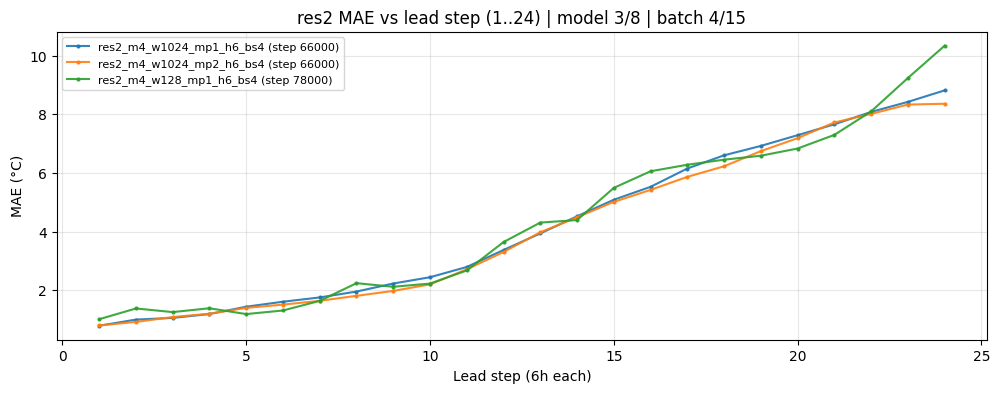

KeyboardInterrupt: 

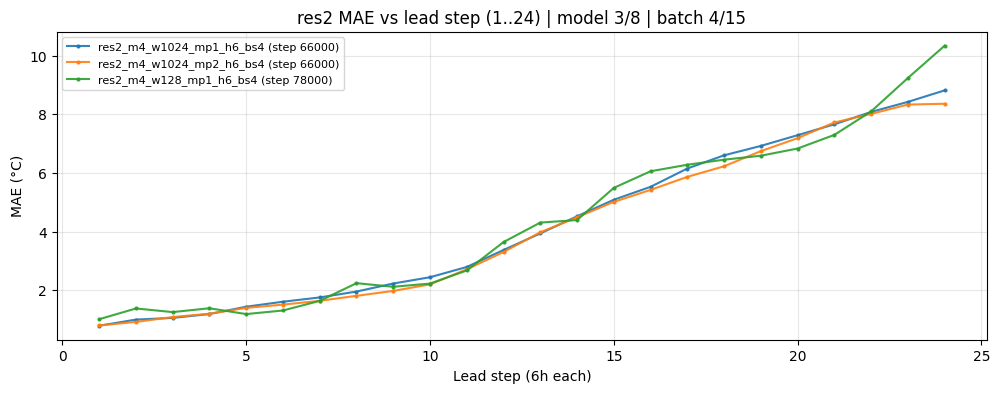

In [39]:
# MAE vs lead step (1..24) for each res2 checkpoint at NYC (batched + live progress)
if "ckpt_paths" not in globals() or len(ckpt_paths) == 0:
    raise RuntimeError("ckpt_paths is empty. Run the checkpoint discovery/evaluation cell first.")
if "ds_nyc" not in globals():
    raise RuntimeError("ds_nyc is missing. Run the NYC data-loading cell first.")

from graphcast import graphcast as graphcast_module
from IPython.display import clear_output, display
import re

max_lead_steps = 24
lead_steps = np.arange(1, max_lead_steps + 1)
lead_hours = max_lead_steps * HOURS_PER_STEP
lead_times_eval = slice(f"{HOURS_PER_STEP}h", f"{lead_hours}h")
refresh_every_batches = 1  # set >1 to refresh less often
window_batch_size = 8      # larger = faster but more memory

def _with_configs_ckpt_local(fn, model_config, task_config):
    return functools.partial(fn, model_config=model_config, task_config=task_config)

def _with_params_ckpt_local(fn, params, state):
    return functools.partial(fn, params=params, state=state)

def _build_eval_batch(ds_res, task_cfg, idx_batch, lat_idx, lon_idx):
    inputs_list, targets_list, forcings_list, real_list = [], [], [], []
    for target_idx in idx_batch:
        window = ds_res.isel(time=slice(target_idx - (n_input_steps + max_lead_steps) + 1, target_idx + 1))
        if window.sizes["time"] < n_input_steps + max_lead_steps:
            continue

        in_i, tgt_i, forc_i = data_utils.extract_inputs_targets_forcings(
            window,
            target_lead_times=lead_times_eval,
            **dataclasses.asdict(task_cfg),
        )
        for name in getattr(graphcast_module, "STATIC_VARS", ("geopotential_at_surface", "land_sea_mask")):
            if name in in_i and "time" in in_i[name].dims:
                in_i = in_i.assign({name: in_i[name].isel(time=0, drop=True)})

        inputs_list.append(in_i.isel(batch=0, drop=True))
        targets_list.append(tgt_i.isel(batch=0, drop=True))
        forcings_list.append(forc_i.isel(batch=0, drop=True))

        real_series = np.asarray(
            ds_res["2m_temperature"].isel(
                time=slice(target_idx - max_lead_steps + 1, target_idx + 1),
                batch=0,
                lat=lat_idx,
                lon=lon_idx,
            ).values
        )
        real_list.append(real_series)

    if not inputs_list:
        return None

    b = len(inputs_list)
    inputs_b = xarray.concat(inputs_list, dim="batch").assign_coords(batch=np.arange(b))
    targets_b = xarray.concat(targets_list, dim="batch").assign_coords(batch=np.arange(b))
    forcings_b = xarray.concat(forcings_list, dim="batch").assign_coords(batch=np.arange(b))
    real_b = np.stack(real_list, axis=0)  # [batch, time]
    return inputs_b, targets_b, forcings_b, real_b

def _sort_key_from_run_name(run_name: str):
    m_w = re.search(r"_w(\d+)_", run_name)
    m_mp = re.search(r"_mp(\d+)_", run_name)
    width = int(m_w.group(1)) if m_w else 10**9
    mp = int(m_mp.group(1)) if m_mp else 10**9
    return (width, mp, run_name)

ordered_ckpt_paths = sorted(ckpt_paths, key=lambda p: _sort_key_from_run_name(p.parent.name))

mae_by_model = {}
fig, ax = plt.subplots(figsize=(12, 4))
total_models = len(ordered_ckpt_paths)
all_target_indices = list(range(start_target_idx, n_steps))
num_batches = (len(all_target_indices) + window_batch_size - 1) // window_batch_size

# Single blue gradient for all models (lighter -> darker as order increases).
cmap = plt.cm.Blues
model_colors = [cmap(v) for v in np.linspace(0.45, 0.95, total_models)]

for m_i, ckpt_path in enumerate(ordered_ckpt_paths, start=1):
    with ckpt_path.open("rb") as f:
        ckpt = checkpoint.load(f, graphcast.CheckPoint)

    model_cfg = ckpt.model_config
    task_cfg = ckpt.task_config
    run_name = ckpt_path.parent.name
    label = f"{run_name} (step {ckpt_path.stem.replace('ckpt_step', '')})"

    res = getattr(model_cfg, "resolution", 1.0)
    stride = max(1, int(round(res)))
    if stride > 1:
        ds_res = ds_nyc.isel(lat=slice(0, None, stride), lon=slice(0, None, stride))
    else:
        ds_res = ds_nyc

    lat_idx = int(np.argmin(np.abs(ds_res["lat"].values - LAT_NYC)))
    lon_idx = int(np.argmin(np.abs(ds_res["lon"].values - LON_NYC)))

    run_jitted = drop_state(
        _with_params_ckpt_local(
            jax.jit(_with_configs_ckpt_local(run_forward.apply, model_cfg, task_cfg)),
            ckpt.params,
            {},
        )
    )

    abs_err_sum = np.zeros(max_lead_steps, dtype=float)
    counts = np.zeros(max_lead_steps, dtype=int)
    model_color = model_colors[m_i - 1]
    line, = ax.plot(
        lead_steps,
        np.full(max_lead_steps, np.nan),
        marker="o",
        markersize=2,
        alpha=0.9,
        color=model_color,
        label=label,
    )

    for b_i in range(num_batches):
        i0 = b_i * window_batch_size
        i1 = min((b_i + 1) * window_batch_size, len(all_target_indices))
        idx_batch = all_target_indices[i0:i1]

        batch_pack = _build_eval_batch(ds_res, task_cfg, idx_batch, lat_idx, lon_idx)
        if batch_pack is None:
            continue
        inputs_b, targets_b, forcings_b, real_b = batch_pack

        pred_b = rollout.chunked_prediction(
            run_jitted,
            rng=jax.random.PRNGKey(5000 + m_i * 100000 + b_i),
            inputs=inputs_b,
            targets_template=targets_b * np.nan,
            forcings=forcings_b,
        )

        pred_bt = np.asarray(
            pred_b["2m_temperature"].isel(lat=lat_idx, lon=lon_idx).transpose("batch", "time").values
        )
        n = min(max_lead_steps, pred_bt.shape[1], real_b.shape[1])
        if n == 0:
            continue

        err_bt = np.abs(pred_bt[:, :n] - real_b[:, :n])
        abs_err_sum[:n] += np.sum(err_bt, axis=0)
        counts[:n] += err_bt.shape[0]

        mae_running = np.divide(
            abs_err_sum,
            counts,
            out=np.full(max_lead_steps, np.nan, dtype=float),
            where=counts > 0,
        )
        line.set_ydata(mae_running)

        if (b_i % refresh_every_batches == 0) or (b_i + 1 == num_batches):
            ax.relim()
            ax.autoscale_view()
            ax.set_xlabel("Lead step (6h each)")
            ax.set_ylabel("MAE (°C)")
            ax.set_title(
                f"res2 MAE vs lead step (1..24) | model {m_i}/{total_models} | "
                f"batch {b_i + 1}/{num_batches}"
            )
            ax.grid(True, alpha=0.3)
            ax.legend(loc="best", fontsize=8)
            clear_output(wait=True)
            display(fig)

    mae_by_model[label] = np.divide(
        abs_err_sum,
        counts,
        out=np.full(max_lead_steps, np.nan, dtype=float),
        where=counts > 0,
    )

ax.set_xlabel("Lead step (6h each)")
ax.set_ylabel("MAE (°C)")
ax.set_title("NYC MAE vs lead step (1..24) for res2_stream checkpoints")
ax.grid(True, alpha=0.3)
ax.legend(loc="best", fontsize=8)
clear_output(wait=True)
display(fig)

print("Computed MAE curves for", len(mae_by_model), "models.")

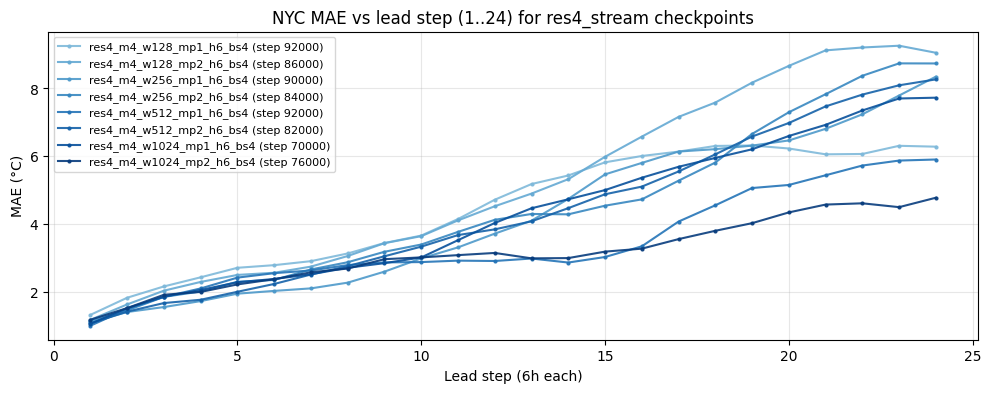

Computed MAE curves for 8 res4 models.


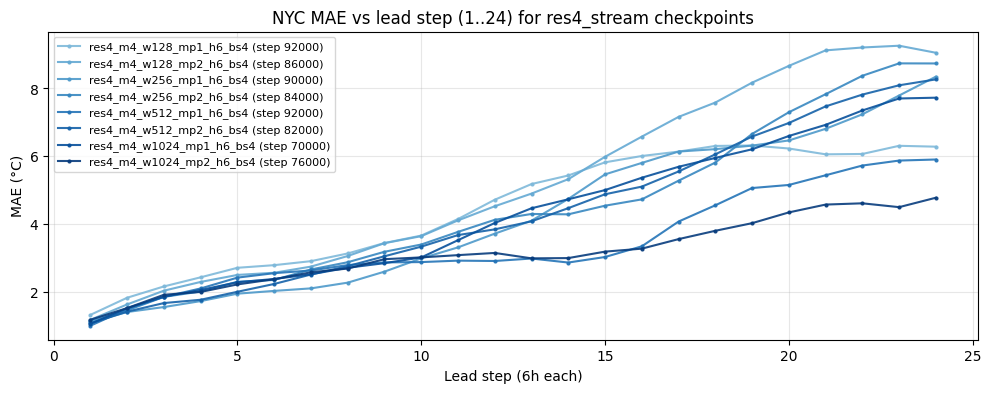

In [40]:
# MAE vs lead step (1..24) for each res4 checkpoint at NYC (batched + live progress)
if "ds_nyc" not in globals():
    raise RuntimeError("ds_nyc is missing. Run the NYC data-loading cell first.")

from graphcast import graphcast as graphcast_module
from IPython.display import clear_output, display
import re

# Ensure ERA5 truth is available on 4° grid via shared regrid helper.
if "ds_nyc_res4" not in globals():
    ds_nyc_res4 = regrid_dataset_resolution(ds_nyc, 4.0, method=REGRID_METHOD)
print("ds_nyc grid:", ds_nyc.sizes.get("lat"), "x", ds_nyc.sizes.get("lon"))
print("ds_nyc_res4 grid:", ds_nyc_res4.sizes.get("lat"), "x", ds_nyc_res4.sizes.get("lon"))
print(f"Regrid method: {REGRID_METHOD}")

RES4_CKPT_DIR = ROOT / "artifacts/checkpoints/graphcast_res4_stream"
ckpt_paths_res4 = []
for run_dir in sorted(RES4_CKPT_DIR.glob("res4_*")):
    if not run_dir.is_dir():
        continue
    candidates = []
    for p in run_dir.glob("ckpt_step*.npz"):
        m = re.search(r"ckpt_step(\d+)$", p.stem)
        if m:
            candidates.append((int(m.group(1)), p))
    if candidates:
        ckpt_paths_res4.append(max(candidates, key=lambda x: x[0])[1])

if not ckpt_paths_res4:
    raise RuntimeError(f"No res4 checkpoints found under {RES4_CKPT_DIR}")

max_lead_steps = 24
lead_steps = np.arange(1, max_lead_steps + 1)
lead_hours = max_lead_steps * HOURS_PER_STEP
lead_times_eval = slice(f"{HOURS_PER_STEP}h", f"{lead_hours}h")
refresh_every_batches = 1  # set >1 to refresh less often
window_batch_size = 8      # larger = faster but more memory

def _with_configs_ckpt_res4(fn, model_config, task_config):
    return functools.partial(fn, model_config=model_config, task_config=task_config)

def _with_params_ckpt_res4(fn, params, state):
    return functools.partial(fn, params=params, state=state)

def _build_eval_batch_res4(ds_res, task_cfg, idx_batch, lat_idx, lon_idx):
    inputs_list, targets_list, forcings_list, real_list = [], [], [], []
    for target_idx in idx_batch:
        window = ds_res.isel(time=slice(target_idx - (n_input_steps + max_lead_steps) + 1, target_idx + 1))
        if window.sizes["time"] < n_input_steps + max_lead_steps:
            continue

        in_i, tgt_i, forc_i = data_utils.extract_inputs_targets_forcings(
            window,
            target_lead_times=lead_times_eval,
            **dataclasses.asdict(task_cfg),
        )
        for name in getattr(graphcast_module, "STATIC_VARS", ("geopotential_at_surface", "land_sea_mask")):
            if name in in_i and "time" in in_i[name].dims:
                in_i = in_i.assign({name: in_i[name].isel(time=0, drop=True)})

        inputs_list.append(in_i.isel(batch=0, drop=True))
        targets_list.append(tgt_i.isel(batch=0, drop=True))
        forcings_list.append(forc_i.isel(batch=0, drop=True))

        real_series = np.asarray(
            ds_res["2m_temperature"].isel(
                time=slice(target_idx - max_lead_steps + 1, target_idx + 1),
                batch=0,
                lat=lat_idx,
                lon=lon_idx,
            ).values
        )
        real_list.append(real_series)

    if not inputs_list:
        return None

    b = len(inputs_list)
    inputs_b = xarray.concat(inputs_list, dim="batch").assign_coords(batch=np.arange(b))
    targets_b = xarray.concat(targets_list, dim="batch").assign_coords(batch=np.arange(b))
    forcings_b = xarray.concat(forcings_list, dim="batch").assign_coords(batch=np.arange(b))
    real_b = np.stack(real_list, axis=0)
    return inputs_b, targets_b, forcings_b, real_b

def _sort_key_from_run_name(run_name: str):
    m_w = re.search(r"_w(\d+)_", run_name)
    m_mp = re.search(r"_mp(\d+)_", run_name)
    width = int(m_w.group(1)) if m_w else 10**9
    mp = int(m_mp.group(1)) if m_mp else 10**9
    return (width, mp, run_name)

ordered_ckpt_paths_res4 = sorted(ckpt_paths_res4, key=lambda p: _sort_key_from_run_name(p.parent.name))

mae_by_model_res4 = {}
fig, ax = plt.subplots(figsize=(12, 4))
total_models = len(ordered_ckpt_paths_res4)
regrid_cache_res4 = {1: ds_nyc, 2: globals().get("ds_nyc_res2", regrid_dataset_resolution(ds_nyc, 2.0, method=REGRID_METHOD)), 4: ds_nyc_res4}
all_target_indices = list(range(start_target_idx, n_steps))
num_batches = (len(all_target_indices) + window_batch_size - 1) // window_batch_size

# Single blue gradient for all models (lighter -> darker as order increases).
cmap = plt.cm.Blues
model_colors = [cmap(v) for v in np.linspace(0.45, 0.95, total_models)]

for m_i, ckpt_path in enumerate(ordered_ckpt_paths_res4, start=1):
    with ckpt_path.open("rb") as f:
        ckpt = checkpoint.load(f, graphcast.CheckPoint)

    model_cfg = ckpt.model_config
    task_cfg = ckpt.task_config
    run_name = ckpt_path.parent.name
    label = f"{run_name} (step {ckpt_path.stem.replace('ckpt_step', '')})"

    res = getattr(model_cfg, "resolution", 1.0)
    stride = max(1, int(round(res)))
    if stride != 4:
        print(f"Warning: {label} has resolution={res}, expected ~4.0")

    if stride not in regrid_cache_res4:
        regrid_cache_res4[stride] = regrid_dataset_resolution(ds_nyc, float(stride), method=REGRID_METHOD)
    ds_res = regrid_cache_res4[stride]

    lat_idx = int(np.argmin(np.abs(ds_res["lat"].values - LAT_NYC)))
    lon_idx = int(np.argmin(np.abs(ds_res["lon"].values - LON_NYC)))

    run_jitted = drop_state(
        _with_params_ckpt_res4(
            jax.jit(_with_configs_ckpt_res4(run_forward.apply, model_cfg, task_cfg)),
            ckpt.params,
            {},
        )
    )

    abs_err_sum = np.zeros(max_lead_steps, dtype=float)
    counts = np.zeros(max_lead_steps, dtype=int)
    model_color = model_colors[m_i - 1]
    line, = ax.plot(
        lead_steps,
        np.full(max_lead_steps, np.nan),
        marker="o",
        markersize=2,
        alpha=0.9,
        color=model_color,
        label=label,
    )

    for b_i in range(num_batches):
        i0 = b_i * window_batch_size
        i1 = min((b_i + 1) * window_batch_size, len(all_target_indices))
        idx_batch = all_target_indices[i0:i1]

        batch_pack = _build_eval_batch_res4(ds_res, task_cfg, idx_batch, lat_idx, lon_idx)
        if batch_pack is None:
            continue
        inputs_b, targets_b, forcings_b, real_b = batch_pack

        pred_b = rollout.chunked_prediction(
            run_jitted,
            rng=jax.random.PRNGKey(7000 + m_i * 100000 + b_i),
            inputs=inputs_b,
            targets_template=targets_b * np.nan,
            forcings=forcings_b,
        )

        pred_bt = np.asarray(
            pred_b["2m_temperature"].isel(lat=lat_idx, lon=lon_idx).transpose("batch", "time").values
        )
        n = min(max_lead_steps, pred_bt.shape[1], real_b.shape[1])
        if n == 0:
            continue

        err_bt = np.abs(pred_bt[:, :n] - real_b[:, :n])
        abs_err_sum[:n] += np.sum(err_bt, axis=0)
        counts[:n] += err_bt.shape[0]

        mae_running = np.divide(
            abs_err_sum,
            counts,
            out=np.full(max_lead_steps, np.nan, dtype=float),
            where=counts > 0,
        )
        line.set_ydata(mae_running)

        if (b_i % refresh_every_batches == 0) or (b_i + 1 == num_batches):
            ax.relim()
            ax.autoscale_view()
            ax.set_xlabel("Lead step (6h each)")
            ax.set_ylabel("MAE (°C)")
            ax.set_title(
                f"res4 MAE vs lead step (1..24) | model {m_i}/{total_models} | "
                f"batch {b_i + 1}/{num_batches}"
            )
            ax.grid(True, alpha=0.3)
            ax.legend(loc="best", fontsize=8)
            clear_output(wait=True)
            display(fig)

    mae_by_model_res4[label] = np.divide(
        abs_err_sum,
        counts,
        out=np.full(max_lead_steps, np.nan, dtype=float),
        where=counts > 0,
    )

ax.set_xlabel("Lead step (6h each)")
ax.set_ylabel("MAE (°C)")
ax.set_title("NYC MAE vs lead step (1..24) for res4_stream checkpoints")
ax.grid(True, alpha=0.3)
ax.legend(loc="best", fontsize=8)
clear_output(wait=True)
display(fig)

print("Computed MAE curves for", len(mae_by_model_res4), "res4 models.")